# รายงานทุเรียน 5 จังหวัด — เปิดไฟล์นี้ไฟล์เดียว

**ผลรันบันทึกไว้แล้ว เลื่อนลงอ่านได้เลย ไม่ต้องเปิด Terminal**

หากต้องการเปลี่ยนช่วงเวลา: กด **Run All** ครั้งเดียว แล้วเลือกจังหวัด ปี เดือนจากเมนู รายงานด้านล่างจะเปลี่ยนพร้อมกัน
เลือก kernel จาก Python environment ที่ใช้งานได้ ไม่เลือก `.venv` เก่า (Python 3.9.5)
สำเนานี้ใช้ `.venv-portfolio/Scripts/python.exe` ในโฟลเดอร์ portfolio; ติดตั้ง requirements ตาม README ก่อน Run All

## สรุปและขอบเขต
เพิ่มการตรวจข้อมูลและผลทดลองโมเดล 28 ก.ย. 2569 แล้ว ดูหัวข้อ 8 ในรายงาน
รายงานฉบับล่าสุดนี้ใช้ข้อมูลที่ดาวน์โหลดไว้ถึงรอบ 26 ก.ย. 2569 ไม่ใช่ข้อมูลสด
เปิดตัวอย่าง **สุราษฎร์ธานี กรกฎาคม 2568** ให้ตรงกับตัวอย่างหน้ารายเดือนเดิม
รวมอากาศ ผลผลิต กรอบระยะ ข่าวจริง และข้อมูลดินในสมุดเดียว
อากาศเป็น NASA POWER ณ จุดอ้างอิงจังหวัด ผลผลิตเป็นยอดทั้งจังหวัดทุกพันธุ์ ไม่ใช่สุขภาพต้นทุเรียนรายต้น

[เปิดแผนที่คลิกชุดดิน](http://127.0.0.1:8871/research_data/five_province_history/UNIFIED_MAP.html)
— แผนที่โต้ตอบยังอยู่หน้าเดิม ต้องเปิดเซิร์ฟเวอร์; ตารางและกราฟด้านล่างอ่านได้โดยไม่ใช้เซิร์ฟเวอร์

In [1]:
# แก้เฉพาะ 3 บรรทัดนี้ แล้ว Run All
PROVINCE = "84"  # 22 จันทบุรี, 33 ศรีสะเกษ, 53 อุตรดิตถ์, 84 สุราษฎร์ธานี, 86 ชุมพร
YEAR = 2025      # ปี ค.ศ.
MONTH = 7        # เดือน 1–12

## 1. โหลดข้อมูลและตรวจคีย์
ใช้ CSV เดิมในโปรเจกต์ ไม่ดาวน์โหลดใหม่และไม่เปลี่ยนข้อมูลต้นฉบับ
วันอากาศเป็น Local Solar Time; ช่องว่างไม่เติมเป็นศูนย์
ปฏิทินกรมวิชาการเกษตรเป็นกรอบภูมิภาค ไม่ใช่ระยะจริงที่สังเกตทุกปี

In [2]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

root = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'research_data/five_province_history').is_dir()), None)
if root is None:
    raise FileNotFoundError('เปิด notebook จากโฟลเดอร์ project ที่มี research_data อยู่ด้วย')
base = root / 'research_data/five_province_history'
def load(name):
    return pd.read_csv(base / name, dtype={'province_code': str})
weather = load('weather_monthly.csv')
harvest = load('harvest_monthly.csv').rename(columns={'month_number': 'month'})
points = load('reference_points.csv')
evidence = json.loads((base / 'phenology_evidence.json').read_text(encoding='utf-8'))
assert not weather.duplicated(['province_code', 'year_ce', 'month']).any()
assert not harvest.duplicated(['province_code', 'year_ce', 'month']).any()
assert PROVINCE in set(points.province_code) and 1 <= MONTH <= 12
name = points.set_index('province_code').loc[PROVINCE, 'province_name']
def table(frame):
    display(frame.style.format(precision=2, na_rep='—').hide(axis='index').set_table_styles([
        {'selector':'th', 'props':[('text-align','left'),('border-bottom','1px solid #aaa')]},
        {'selector':'td', 'props':[('border-bottom','1px solid #eee'),('padding','7px')]}
    ]))
print(f'อากาศรายเดือน {len(weather):,} แถว; ผลผลิตรายเดือนที่มีระเบียน {len(harvest):,} แถว')

อากาศรายเดือน 2,745 แถว; ผลผลิตรายเดือนที่มีระเบียน 748 แถว


## โค้ดรายงาน (พับไว้ได้)
ตารางและกราฟใช้ข้อมูลชุดเดียวกับรายงานเดิม ไม่ดาวน์โหลดใหม่เมื่อเปลี่ยนเดือน

In [3]:
def render_report(PROVINCE, YEAR, MONTH):
    assert PROVINCE in set(points.province_code) and 1 <= MONTH <= 12
    name = points.set_index('province_code').loc[PROVINCE, 'province_name']
    display(Markdown(f'# {name} · เดือน {MONTH} ปี {YEAR + 543}'))
    display(Markdown('## 2. เปรียบเทียบห้าจังหวัดในเดือนเดียวกัน\nอากาศจุดอ้างอิงจังหวัด ไม่ใช่ค่าเฉลี่ยเชิงพื้นที่จังหวัดหรืออำเภอ ฝนเดือนที่วันไม่ครบคือยอดเฉพาะวันที่มีค่า'))

    selected_weather = weather[(weather.year_ce == YEAR) & (weather.month == MONTH)]
    selected_harvest = harvest[(harvest.year_ce == YEAR) & (harvest.month == MONTH)]
    comparison = points[['province_code', 'province_name']].merge(selected_weather, on='province_code', how='left', validate='one_to_one').merge(selected_harvest[['province_code', 'tonnes']], on='province_code', how='left', validate='one_to_one')
    table(comparison[['province_name','temperature_c','rain_mm','humidity_pct','solar_mj_m2_day','tonnes']].rename(columns={
        'province_name':'จังหวัด','temperature_c':'อุณหภูมิ °C','rain_mm':'ฝนรวม มม.',
        'humidity_pct':'RH %','solar_mj_m2_day':'แสง MJ/m²/วัน','tonnes':'ผลผลิต ตัน'}))
    table(comparison[['province_name','days_temperature','days_rain','expected_days']].rename(columns={
        'province_name':'จังหวัด','days_temperature':'วันมีอุณหภูมิ','days_rain':'วันมีฝน','expected_days':'วันทั้งเดือน'}))

    display(Markdown('## 3. อากาศและผลผลิตทั้งปีของจังหวัดที่เลือก\nแยกแกนคนละกราฟเพราะหน่วยต่างกัน เส้นขาดคือข้อมูลหาย ไม่ใช่ศูนย์ ไม่มีช่วงความเชื่อมั่นในต้นทาง และกราฟนี้ไม่พิสูจน์สาเหตุของผลผลิต'))

    plt.rcParams.update({'font.family':'Tahoma','font.size':12,'axes.spines.top':False,
                         'axes.spines.right':False,'axes.edgecolor':'#6F6F6F',
                         'figure.facecolor':'white','axes.facecolor':'white'})
    months = pd.DataFrame({'month': range(1,13)})
    year_data = months.merge(weather[(weather.province_code == PROVINCE) & (weather.year_ce == YEAR)], on='month', how='left', validate='one_to_one')
    year_data = year_data.merge(harvest[(harvest.province_code == PROVINCE) & (harvest.year_ce == YEAR)][['month','tonnes']], on='month', how='left', validate='one_to_one')
    fig, axes = plt.subplots(3, 1, figsize=(10,9), sharex=True, constrained_layout=True)
    for ax, metric, title in zip(axes, ['temperature_c','rain_mm','tonnes'], ['อุณหภูมิเฉลี่ย (°C)','ฝนรวม (มม.)','ผลผลิตทั้งจังหวัด ทุกพันธุ์ (ตัน)']):
        if metric == 'tonnes':
            ax.bar(year_data.month, year_data[metric], color='#1F6F5F', width=.65)
            ax.set_ylim(bottom=0)
        else:
            ax.plot(year_data.month, year_data[metric], color='#1F6F5F', marker='o', linewidth=1.7)
            if metric == 'rain_mm': ax.set_ylim(bottom=0)
        ax.set_title(title, loc='left', fontsize=13)
        ax.grid(axis='y', color='#E8E8E5', linewidth=.6)
        ax.set_axisbelow(True)
        if not year_data[metric].notna().any():
            ax.text(.5,.5,'ไม่มีข้อมูลในปีนี้',transform=ax.transAxes,ha='center')
    axes[-1].set_xticks(range(1,13))
    axes[-1].set_xlabel('เดือน')
    fig.suptitle(f'{name} ปี {YEAR + 543} — อากาศจุดอ้างอิงและผลผลิตจังหวัด', fontsize=15)
    plt.show()
    display(Markdown('แหล่ง: [NASA POWER](https://power.larc.nasa.gov/docs/services/api/temporal/daily/) และ [สศก. รายเดือน](https://catalog.oae.go.th/dataset/durian_product_month)'))

    display(Markdown('## 4. ช่วงนี้เป็นระยะไหน\nกรอบหมอนทองในฤดูตามคู่มือ ไม่ยืนยันต้นจริง ภาคใต้มีหลายระยะทับซ้อนกันในระดับภูมิภาค ไม่หมายถึงต้นเดียวอยู่ทุกระยะพร้อมกัน'))

    region = next(r for r in evidence['regions'].values() if PROVINCE in r['provinces'])
    calendar_rows = []
    for month in range(1,13):
        phases = [evidence['stages'][p['stage']]['short'] for p in region['periods'] if month in p['months']]
        calendar_rows.append({'เดือน':month, 'กรอบระยะทั่วไป':' / '.join(phases)})
    table(pd.DataFrame(calendar_rows))
    source = evidence['calendar_source']
    display(Markdown(f"ที่มา: [{source['title']}]({source['url']}) · {source['locator']}"))
    display(Markdown('**เดือนที่เลือก:** ' + calendar_rows[MONTH-1]['กรอบระยะทั่วไป']))

    display(Markdown('## 5. ข่าวและรายงานที่ตรงเดือน–ปี\nกรองตามเดือนเกิดเหตุหรือวันกำหนด ไม่ใช่เดือนเผยแพร่ข่าว ข่าวปีอื่นไม่ถูกนำมาแทน'))

    events = [e for e in evidence['events'] if e['province_code'] == PROVINCE and e['year'] == YEAR and MONTH in e['months']]
    if not events:
        display(Markdown('ยังไม่มีรายงานที่ตรวจยืนยันในฐานสำหรับเดือน–ปีนี้ **ไม่ได้แปลว่าไม่มีเหตุการณ์**'))
    for e in events:
        display(Markdown(f"### {e['title']}\n{e['summary']}\n\nวันเหตุ/กำหนด: {e['event_date']} · เผยแพร่: {e.get('published_date') or 'ไม่ระบุ'}\n\n[อ่านต้นทาง]({e['url']})"))

    display(Markdown('## 6. ข้อมูลดินในจังหวัด\nเป็นคุณสมบัติตามแผนที่ ไม่ใช่ผลตรวจดินสวนปัจจุบัน ตารางตัวอย่างไม่ใช่จัดอันดับพื้นที่ปลูก ห้ามแจกผลผลิตจังหวัดลงดินแต่ละชุด'))

    soil = pd.read_csv(base / 'soil_properties_by_district.csv')
    province_column = 'province' if 'province' in soil.columns else 'province_name'
    selected_soil = soil[soil[province_column].astype(str).str.contains(name, regex=False)]
    print(f'พบ {len(selected_soil):,} ระเบียน แสดง 10 แถวแรก')
    table(selected_soil[['district','soil_code','soil_name','fertility','topsoil_ph','topsoil_texture']].head(10).rename(columns={
        'district':'อำเภอ','soil_code':'รหัสดิน','soil_name':'ชุดดิน','fertility':'ความอุดมสมบูรณ์','topsoil_ph':'ปฏิกิริยาดิน','topsoil_texture':'เนื้อดิน'}))
    display(Markdown('ที่มา: กรมพัฒนาที่ดิน ปี 2561 แผนที่ต้นฉบับ 1:25,000 ไม่ใช้ระบุแนวเขตแปลง'))

    display(Markdown('## 7. ข้อมูลที่เตรียมไว้เทรน\nชุดนี้ใช้ทดลอง baseline แล้ว ยังไม่ใช่โมเดลใช้งานจริง เป้าหมายคือผลผลิตรายเดือนระดับจังหวัด ไม่ใช่โรคหรือสุขภาพต้น และไม่มีเซนเซอร์สวน/ค่า gateway ค้างปะปน'))

    training = pd.read_csv(base / 'training/monthly_model_panel.csv', dtype={'province_code':str})
    usable = training[training.eligible_for_baseline.eq(1)]
    table(usable.groupby('suggested_split').size().rename('แถวที่เข้าเงื่อนไข').reset_index())
    display(Markdown(f'มีข้อมูลทั้งหมด **{len(training):,} แถว** เข้าเงื่อนไขเบื้องต้น **{len(usable):,} แถว** ไม่เติม target ที่ขาดเป็นศูนย์'))
    print('ไฟล์ข้อมูล:', base / 'training/monthly_model_panel.csv')
    print('รวมไฟล์สำหรับย้ายเครื่อง:', base / 'training/training_bundle.zip')

    display(Markdown('## 8. ผลทดลองโมเดลและการตรวจข้อมูล\nแยก train ถึง 2021, validation 2022–2023, test 2024–2025 โมเดลเลือกจาก validation เท่านั้น MAE เป็นตันต่อจังหวัด–เดือน ไม่ใช่เปอร์เซ็นต์ความแม่นยำ'))

    metrics = pd.read_csv(base / 'training/model_metrics.csv', dtype={'province_code':str})
    model_info = json.loads((base / 'training/model_baseline.json').read_text(encoding='utf-8'))
    table(metrics[metrics.province_code.eq('ALL')][['model','split','n','mae_tonnes']].rename(columns={'model':'โมเดล','split':'ชุดประเมิน','n':'จำนวนเดือน–จังหวัด','mae_tonnes':'MAE ตัน'}))
    display(Markdown('**โมเดลที่เลือกจาก validation:** ' + model_info['selected_by_validation']))
    display(Markdown('ทดลองรอบนี้การเพิ่มอากาศเดือนก่อนยังไม่ดีกว่าโมเดลจังหวัด–เดือนอย่างเดียว ไม่ใช่หลักฐานว่าอากาศไม่มีผลต่อทุเรียน และไม่ใช้สั่งให้น้ำ/วินิจฉัยโรค'))
    display(Markdown('QC: ตรวจคีย์ไม่ซ้ำ ค่าที่ขาด ช่วงค่า RH/ฝน/แสง และคำนวณอุณหภูมิ ฝน RH แสงรายเดือนกลับจากรายวัน เทรนเฉพาะแถวที่อากาศเดือนก่อนครบทั้ง 4 ตัวแปร ข้อมูลผลผลิตที่ไม่มีแถวไม่เติมศูนย์'))
    display(Markdown('ข้อจำกัด: ประเมินเฉพาะเดือนที่มีผลผลิตรายงาน มีเพียง 5 จังหวัด ไม่ใช่ backtest ตามข้อมูลที่ทราบจริงในวันนั้น เพราะวันเผยแพร่และการปรับปรุงย้อนหลังยังไม่ครบ'))

    display(Markdown('## 9. ทดลองอากาศย้อนหลัง 1–6 เดือนกับผลผลิตต่อไร่รายปี\nผลผลิตต่อไร่ = ผลผลิตตัน × 1,000 ÷ พื้นที่ให้ผล (ไร่) ไม่ใช่พื้นที่ปลูกทั้งหมด\nหนึ่งแถวต่อจังหวัด–ปี ไม่ทำซ้ำเป็น 12 เดือน เดือนอ้างอิงเลือกจากเดือนที่มียอดผลผลิตรวมสูงสุดในข้อมูลฝึกถึงปี 2021 แล้วตรึงไว้ทุกปี ไม่ใช่วันเก็บเกี่ยวจริง\nอากาศเฉลี่ยถ่วงตามจำนวนวัน ฝนเป็นยอดรวม ก่อนเดือนอ้างอิง 1–6 เดือน ผลด้านล่างรวมทั้ง 5 จังหวัด ไม่เปลี่ยนตามตัวเลือกเดือน'))

    annual_scores = pd.read_csv(base / 'training/annual_yield_windows_metrics.csv')
    annual_info = json.loads((base / 'training/annual_yield_windows_info.json').read_text(encoding='utf-8'))
    table(annual_scores.pivot(index='window_months',columns='split',values='mae_kg_rai').reset_index().rename(columns={'window_months':'ย้อนหลังสะสม (0 = ไม่เพิ่มอากาศ)','validation':'MAE validation กก./ไร่','test':'MAE test กก./ไร่'}))
    chosen = annual_info['selected_window_by_validation']
    baseline_mae = annual_scores.query("window_months == 0 and split == 'test'").mae_kg_rai.iloc[0]
    chosen_mae = annual_scores[(annual_scores.window_months == chosen) & (annual_scores.split == 'test')].mae_kg_rai.iloc[0]
    display(Markdown(f'Validation เลือกย้อนหลัง **{chosen} เดือน** แต่ MAE test = **{chosen_mae:,.1f} กก./ไร่** เทียบฐานจังหวัด+แนวโน้มปี **{baseline_mae:,.1f} กก./ไร่** (ต่ำกว่าดีกว่า)'))
    display(Markdown('ข้อมูล 145 จังหวัด–ปี: ฝึก 125, validation 10, test 10 แถว ชุดทดสอบเล็กมาก รอบนี้ยังไม่แสดงว่าการเพิ่มอากาศช่วยทำนายข้อมูลช่วงทดสอบ ไม่ใช่ข้อสรุปว่าอากาศไม่มีผล และไม่ยืนยันสาเหตุ/ระยะพืชจริง'))
    display(Markdown('เดือนอ้างอิงจากข้อมูลฝึก: จันทบุรี พ.ค.; ศรีสะเกษ มิ.ย.; อุตรดิตถ์ ก.ค.; สุราษฎร์ธานีและชุมพร ส.ค. ข้อมูลรายเดือนที่รายงานไม่ครบอาจทำให้เดือนอ้างอิงคลาดเคลื่อน'))

    display(Markdown('## ข้อสรุปที่ใช้ได้และสิ่งที่ยังไม่ทราบ\n- ใช้ดูว่าเดือนเดียวกันแต่ละจังหวัดมีอากาศและผลผลิตต่างกันอย่างไร แล้วตั้งคำถามวิจัยต่อ\n- ระยะทั่วไปไม่ใช่ label ระยะจริงของต้น ส่วนข่าวเป็นทะเบียนตัวอย่างที่ยังไม่ครบทุกพื้นที่\n- ยังสรุปไม่ได้ว่าอากาศทำให้ดอก/ผลร่วงกี่ตัน หรือต้นในสวนต้องให้น้ำเท่าใด ต้องมีวันระยะจริง การจัดการ และผลสังเกตต้น\n- อากาศปี 2569 เป็นช่วงไม่ครบปี ผลผลิตที่รวบรวมถึงปี 2568 ไม่ควรเปรียบเทียบยอดทั้งปีกับปีที่ยังไม่ครบ\n\n### ไฟล์ที่ควรใช้\n**กลับมาเปิด `00_OPEN_ME.ipynb` ไฟล์นี้เป็นหลัก**\nข้อมูลต้นทางยังอยู่ใน `research_data/five_province_history/` ไม่ต้องเปิดไฟล์ HTML ใน `tools/`\nคู่มือแหล่งอ้างอิง: `research_data/five_province_history/PHENOLOGY_SOURCES_TH.md`\nคู่มือเทรน: `research_data/five_province_history/training/README_TH.md`'))



## เลือกพื้นที่และเวลา
เมนูทำงานหลัง Run All และต้องมี kernel เชื่อมอยู่ ถ้ายังไม่รัน อ่านผลตัวอย่างที่บันทึกด้านล่างได้


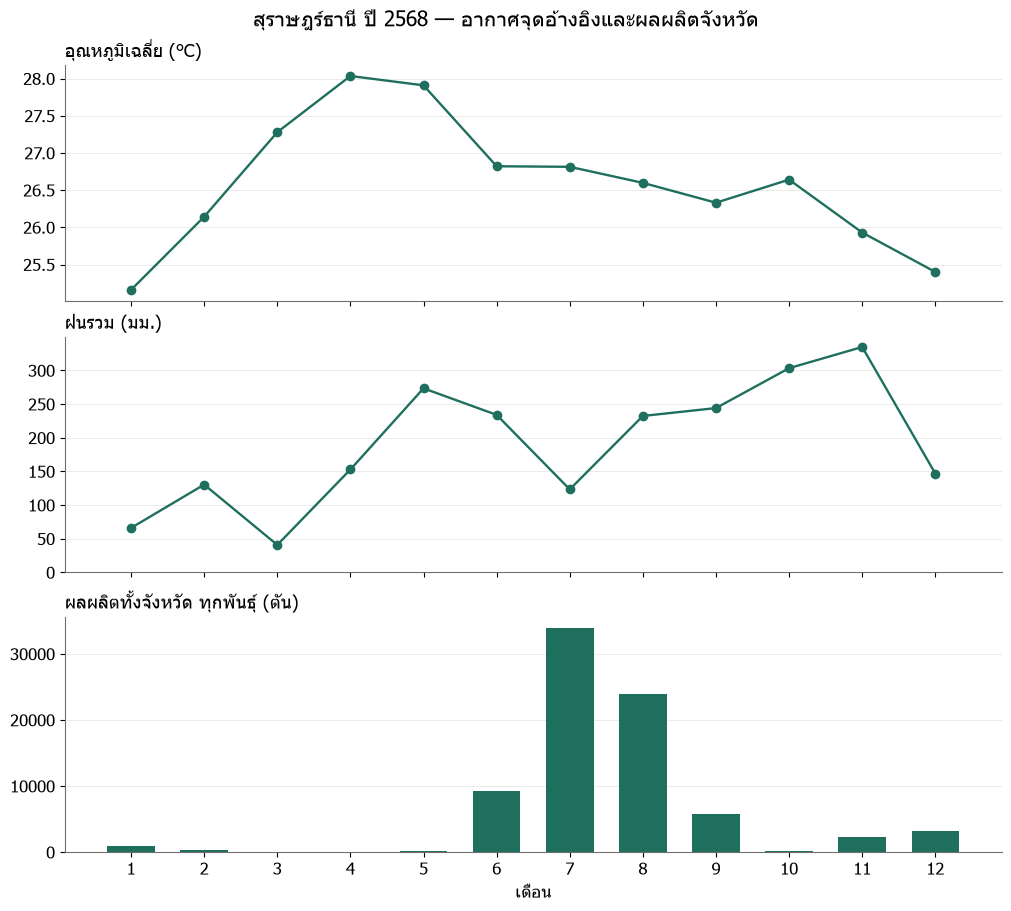

In [4]:
import ipywidgets as widgets
from IPython.utils.capture import capture_output
from IPython.display import HTML
from nbconvert.filters.markdown import markdown2html
from html import escape

province_control = widgets.Dropdown(options=[(r.province_name, r.province_code) for r in points.itertuples()], value=PROVINCE, description='จังหวัด')
year_control = widgets.Dropdown(options=[(str(y+543), y) for y in range(2026,1980,-1)], value=YEAR, description='ปี พ.ศ.')
month_control = widgets.Dropdown(options=list(range(1,13)), value=MONTH, description='เดือน')
def report_html():
    with capture_output(display=True) as captured:
        render_report(province_control.value, year_control.value, month_control.value)
    parts = []
    for item in captured.outputs:
        data = item.data
        if 'text/html' in data: parts.append(data['text/html'])
        elif 'image/png' in data: parts.append('<img style="max-width:100%;height:auto" alt="กราฟอากาศและผลผลิตรายเดือน" src="data:image/png;base64,' + data['image/png'] + '">')
        elif 'text/markdown' in data: parts.append(markdown2html(data['text/markdown']))
        elif 'text/plain' in data: parts.append('<pre>' + escape(data['text/plain']) + '</pre>')
    if captured.stdout: parts.append('<pre>' + escape(captured.stdout) + '</pre>')
    return ''.join(parts)
display(widgets.HBox([province_control, year_control, month_control], layout=widgets.Layout(flex_flow='row wrap')))
live_report = display(HTML(report_html()), display_id=True)
def update_report(change):
    live_report.update(HTML(report_html()))
for control in [province_control, year_control, month_control]:
    control.observe(update_report, names='value')